# **MÓDULO 21 - Projeto de Credit Score - Árvore de Decisão**


No módulo 17, vocês realizaram a primeira etapa do projeto de crédito de vocês. Então fizeram o tratamendo dos dados, balancearam as classes, transformaram as variáveis categóricas e separam base de treino e teste. Já no módulo 14, aplicaram a base já tratada o algoritmo de Naive Bayes, onde avaliaram os resultados das previsões. Nesse módulo aplicaremos a nossa base o algoritmo da árvore de decisão.

In [45]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1) Comece carregando as bases de treino (X e y) e teste (X e y).
Verifique se o número de linhas condiz, se as variáveis estão corretas sendo apenas a de score para y e as demais nas bases de X e por último, se Y está balanceada no teste.

In [46]:
X_test = pd.read_csv(r"Bases\X_test.csv", delimiter=',')
X_train = pd.read_csv(r"Bases\X_train_balanced.csv", delimiter=',')
y_test = pd.read_csv(r"Bases\y_test.csv", delimiter=',')
y_train = pd.read_csv(r"Bases\y_train_balanced.csv", delimiter=',')

In [47]:
X_test

,Age,Income,Number of Children,Gender Encoded,Education Encoded,Marital Encoded,HomeOwnership Encoded
0,25,55000.0,0,0,1,1,1
1,48,87500.0,1,0,2,0,0
2,26,55000.0,1,0,1,0,0
3,39,62500.0,2,0,1,0,0
4,35,90000.0,1,0,2,0,0
5,25,55000.0,0,0,1,1,1
6,48,82500.0,1,0,2,0,0
7,48,82500.0,1,0,2,0,0
8,36,95000.0,2,0,4,0,0
9,37,95000.0,1,0,3,0,0


In [48]:
X_train

,Age,Income,Number of Children,Gender Encoded,Education Encoded,Marital Encoded,HomeOwnership Encoded
0,26,45000.000000,0,0,0,1,1
1,29,27500.000000,0,0,3,1,1
2,25,62500.000000,0,0,1,1,1
3,29,68000.000000,2,0,2,0,0
4,31,65000.000000,0,1,1,1,1
...,...,...,...,...,...,...,...
247,27,36803.652916,0,0,2,1,1
248,27,37500.000000,0,0,3,1,1
249,28,29946.263487,0,0,1,1,1
250,27,35412.944984,0,0,1,1,1


In [49]:
y_test

,CreditScore Encoded
0,0
1,1
2,0
3,1
4,1
5,0
6,1
7,1
8,1
9,1


In [50]:
y_train

,CreditScore Encoded
0,0
1,2
2,0
3,0
4,0
...,...
247,2
248,2
249,2
250,2


# 2) Explique com suas palavras, qual o passo a passo para a aplicação do algoritmo da árvore de decisão, não esqueça de citar a etapa de avaliação do modelo e também como podemos melhorar nosso modelo.

Etapas para aplicar uma árvore de decisão

**1 - Pré- processamento dos dados** 

Nessa etapa é importante, inicialmente, fazer a importação dos dados, seja por banco de dados, API ou como neste caso, realizando importação de arquivos CSV. Geralmente estamos usando a biblioteca pandas para esse fim.

Nesta etapa, também realizamos a limpeza de dados, onde podemos remover dados nulos duplicatas ou inconsistências. Neste caso, realizamos o tratamento de dados faltantes aplicando o valor da média e ajustamos os tipos de dados que melhor definem cada coluna dos dados. Identificação de outliers também deve ser visto nesta etapa.

Também é importante realizar a codificação de variáveis categóricas, elas ajudam a transformar os dados categóricos em dados numéricos para manipulação mais eficiente dos modelos. Utilizando Label Encoder ou one hot.

Após essa revisão dos dados podemos realizar a separação dos dados de treino e de teste com base na coluna predita. É muito importante realizar o balanceamento das bases de treino, para que o modelo tenha como analisar e aprender correlação entre os dados e com isso realizar uma avaliação mais ajustada em bases de teste quando solicitado. 

OBS: Não é obrigatório para a aplicação de modelos de LM  mas, é sempre de bom grado fazer análises exploratória com os dados obtidos como avaliação uni e bi lateral de dados, aferição dos dados para encontrar e trazer insights de suas descobertas.

**2 -  Construção do modelo**

A partir do momento em que todo o pré processamento foi realizado e deixamos os dados limpos e estruturados para a extração de dados de treino e teste, podemos aplicar em algum modelo, que neste caso é o modelo preditivo de árvore de decisão.

Nessa etapa podemos definir como podemos estruturar a árvore em função de classificação ou regressão, também podemos dimensionar o grau de complexidade da árvore como a profundidade máxima da árvore, número mínimo de amostras para dividir um nó e a medida de impureza.

**3 -  Avaliação do modelo**
Nesta etapa trazemos os dados de predição feita pelo modelo. É de suma importância que os mesmo não sejam analisados sozinhos, neste caso podemos trazer métricas de desempenho. Para avaliar o desempenho em função da classificação utilizamos acurácia, precisão(precision) recall , F1-score e matriz de confusão. Já para regressão podemos utilizar o R2 .

**Melhorando o modelo**
Para obter a melhora do modelo, podemos utilizar técnicas de poda, que consistem em definir limites da estrutura das nossas árvores, eliminando partes da árvore que podem ser julgadas desnecessárias ou que podem acarretar em overfitting. Os ajustes de hiperparâmetros também auxiliam nesta questão de melhora do modelo.


# 3) Aplique o algortimo da árvore de decisão aos dados de treinamento, utilizando critério de Gini e random state = 0.
Traga a acurácia para o modedlo com os dados de treino.

In [51]:
# Definindo o classificador
score_credit_classificador = DecisionTreeClassifier(criterion= 'gini', random_state= 0)

# consturindo o modelo com dados de treinamento
score_credit_classificador.fit(X_train, y_train)

DecisionTreeClassifier(random_state=0)

In [52]:
# Retorando a acurácia do modelo com a base de treinamento
previsao_scc_treinamento = score_credit_classificador.predict(X_train)
acuracia_scc_treinamento = accuracy_score(y_train, previsao_scc_treinamento)
print(f"Acurácia do modelo com a base de treinamento: {acuracia_scc_treinamento:.2%}")

# Criando relatório de classificação da base de treinamento
relatorio_treinamento = classification_report(y_train, previsao_scc_treinamento)
print("Relatório de Classificação - Base de Treinamento:\n", relatorio_treinamento)

Acurácia do modelo com a base de treinamento: 100.00%
Relatório de Classificação - Base de Treinamento:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        84
           1       1.00      1.00      1.00        84
           2       1.00      1.00      1.00        84

    accuracy                           1.00       252
   macro avg       1.00      1.00      1.00       252
weighted avg       1.00      1.00      1.00       252



# 4) Aplique o modelo aos dados de teste e realize a avaliação dos resultados. Não se esqueça de avaliar com as suas palavras e comparar o desempenho da base treino com a teste.

In [53]:
# consturindo o modelo com dados de test
score_credit_classificador.fit(X_test, y_test)

DecisionTreeClassifier(random_state=0)

In [54]:
# Retorando a acurácia do modelo com a base de teste
previsao_scc_test = score_credit_classificador.predict(X_test)
acuracia_scc_test = accuracy_score(y_test, previsao_scc_test)
print(f"Acurácia do modelo com a base de teste: {acuracia_scc_test:.2%}")

Acurácia do modelo com a base de teste: 100.00%


In [55]:
# Criando relatório de classificação da base de teste
relatorio_teste = classification_report(y_test, previsao_scc_test)
print("Relatório de Classificação - Base de Teste:\n", relatorio_teste)

Relatório de Classificação - Base de Teste:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00        29
           2       1.00      1.00      1.00         6

    accuracy                           1.00        41
   macro avg       1.00      1.00      1.00        41
weighted avg       1.00      1.00      1.00        41



**Avaliação do desemprenho da base de treino e teste do modelo**

Tanto a base de treino quanto a base de teste estão apresentando uma acurácia de 100%. Assim como a métrica precision , recall e f1-score para todos as classes da nossa variavel target.

Essa avaliação indica que o modelo memorizou com exatidão os dados de treinamento e consegue generalizar o aprendizado para a base de teste com perfeição.

Ou seja, todas as predições, médias ponderadas(weighted avg) e médias simples (macro avg) vão apresentar 100% de exatidão.

Contudo, essa perfeição em cenários reais, são muito difíceis de conseguir, o que pode salientar as questões de overfitting. Isso se deve muito ao tamanho do conjunto de treino e teste.

A árvore de decisão tem uma capacidade de expandir até certo ponto, depois disso ela pode ter um desempenho muito abaixo do esperado  em relação a capacidade de memorização de dados da base de treino.

Analisando o conjunto de testes, temos apenas 41 amostra, podendo não ser o suficiente para acompanhar a complexidade de dados em um mundo real. Provavelmente, com dados de teste diferenciados e em maior quantidade, tenhamos um desempenho muito inferior.

Outro fator que pode contribuir com esses resultados é a qualidade dos dados, os dados são de fácil classificação e estão muito bem separados por features que, pela análise feita nos módulos anteriores, existem features altamente preditivas, ou seja, são muito determinísticas para definição de score de crédito. facilitando muito a compreensão dos dados e determinação de score.

# 5) Plote a árvore de decisão.
É possível fazer uma avaliação visual? Qual a profundidade da árvore?

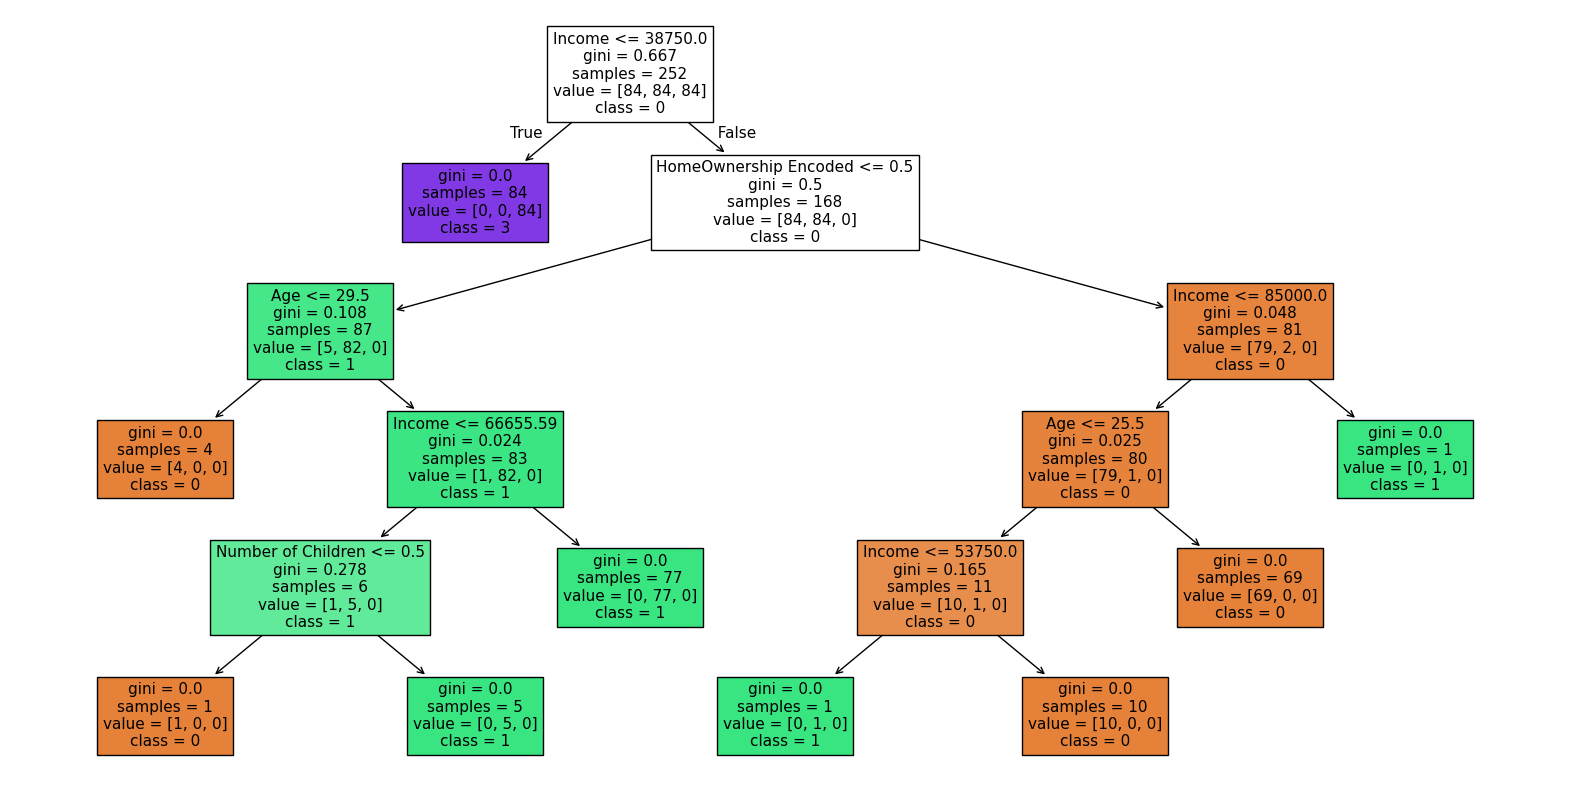

In [59]:
# consturindo o modelo com dados de treinamento
score_credit_classificador.fit(X_train, y_train)

#plotando a árvore de decisão
plt.figure(figsize=(20,10))
plot_tree(score_credit_classificador, filled=True, feature_names=X_train.columns, class_names=['0', '1', '3'], fontsize=11)
plt.show()

**Avaliação visual da árvore**

Conseguimos ter uma visualização bem clara das classes envolvidas no treinamento do modelo. Essa árvore apresenta uma profundidade de 5 níveis (Raiz e mais 5 divisões)

Podemos predizer que a classe mais importante para iniciarmos a árvore de decisão é o `Income`, a partir dela serão avaliados os outros denominadores de classificação

observando que temos na raiz um gini de 0.66, com 252 exemplos de treino neste nó, divididos em 3 classes (0, 1, 2) que representa o score de crédito de cada indivíduo da amostra.


# 6) Identifique as 2 principais features do modelo.


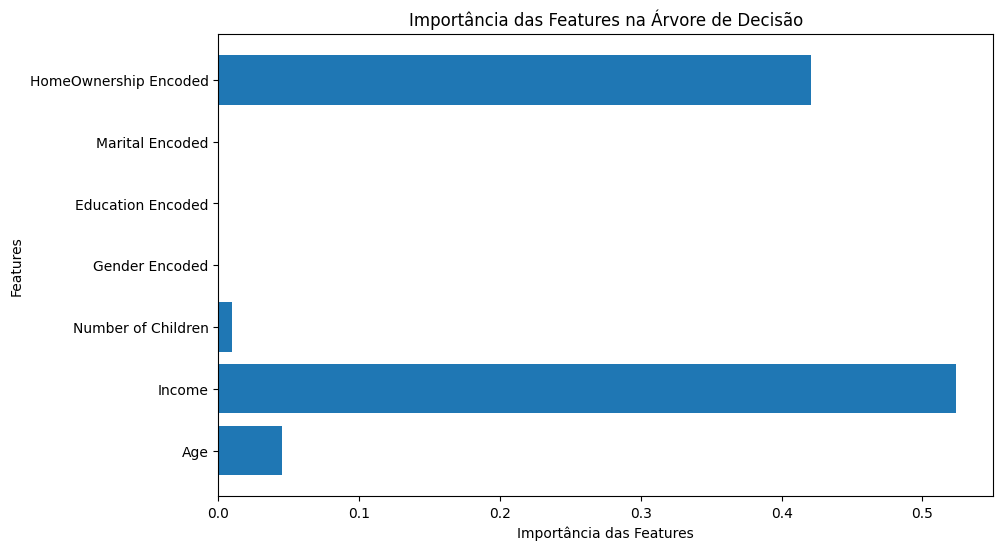

In [57]:
# Obtendo a importância das características do modelo de árvore de decisão
importancias_features = score_credit_classificador.feature_importances_

# Obtendo os nomes das características
nomes_features = X_train.columns

# Criando um gráfico de barras para visualizar a importância das características
plt.figure(figsize=(10, 6))
plt.barh(nomes_features, importancias_features)
plt.xlabel('Importância das Features')
plt.ylabel('Features')
plt.title('Importância das Features na Árvore de Decisão')
plt.show()

# 7) Rode um modelo de árvore de decisão apenas com as 2 principais features encontradas. E avalie os resultados. Para você o desempenho da árvore está melhor que o modelo anterior? Justifique.

In [100]:
# Refinamento da estrutura da árvore com dados ajustafos em função da importância das features
X_train_refinado = X_train[['Income', 'HomeOwnership Encoded']]
X_test_refinado = X_test[['Income', 'HomeOwnership Encoded']]

In [101]:
# Definindo o classificador Filtrado
score_credit_classificador_filtrado = DecisionTreeClassifier(criterion= 'gini', random_state= 0)

# consturindo o modelo com dados de treinamento
score_credit_classificador_filtrado.fit(X_train_refinado, y_train)

DecisionTreeClassifier(random_state=0)

In [102]:
# criando variavel de previsão com dados refinados
previsao_scc_filtrado = score_credit_classificador_filtrado.predict(X_test_refinado)

In [103]:
# Criando relatório de classificação da base de teste refinada
relatorio_teste_filtrado = classification_report(y_test, previsao_scc_filtrado)

In [105]:
print("Relatório de Classificação:")
print(relatorio_teste_filtrado)

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83         6
           1       0.97      0.97      0.97        29
           2       1.00      1.00      1.00         6

    accuracy                           0.95        41
   macro avg       0.93      0.93      0.93        41
weighted avg       0.95      0.95      0.95        41



Avaliação

Ao comparar os resultados dos modelos com e sem filtro de features, podemos observar que houve uma piora nas métricas de avaliação dos resultados.

- Precision
Classe 0 = 83% das amostras previstas como pertencentes à classe 0 realmente são da classe 0
Classe 1 = 97% das amostras previstas como pertencentes à classe 0 realmente são da classe 1
Classe 2 = 100% das amostras previstas como pertencentes à classe 0 realmente são da classe 2

- F1-Score
Classe 0 = Apresenta média harmônica da Precisão de 83% das amostras pertencentes à classe 0 realmente são da classe 0
Classe 1 = Apresenta média harmônica da Precisão de 97% das amostras pertencentes à classe 0 realmente são da classe 0
Classe 2 = Apresenta média harmônica da Precisão de 100% das amostras pertencentes à classe 0 realmente são da classe 0

- Recall
Classe 0 = 83%,indicando que o modelo identificou corretamente 83% das amostras da classe 0.
Classe 1 = 97%, ,indicando que o modelo identificou corretamente 97% das amostras da classe 1.
Classe 2 = 100%,indicando que o modelo identificou corretamente 100% das amostras da classe 2.


A acurácia global foi de 95%, o que significa que a previsão do modelo está correta em 95% das predições

Macro Average: Apresenta media simples das méticas apresenta o valor de 93%

Weighted Average: Apresenta a média ponderada das métricas apresenta o valor de 95%

Isso ocorre pois ao eliminar uma feature de menor importância, ela continha informações importantes e discriminatórias para a árvore de decisão, forçando o modelo a se ajustar com poucos parâmetros de observação. Esse comportamento evidencia a interatividade de mais de uma feature no contexto geral do modelo.
Repetindo novamente, o tamanho da base também reflete nos resultados obtidos por ser de uma base pequena.


# 8) Compare os resultados obtidos com a árvore de decisão com os resultados do Naive Bayes (Exercício módulo 20). Qual parece ter se adequado melhor aos dados e tem melhores resultados de avaliação? Justifique.

**Comparando resultados**

Comparando os dados sem qualquer filtragem (Como ocorreu no modelo de arvore de decisão). ***A Árvore de decisão apresentou um melhor resultado das avaliações***, podendo realizar previsão com 100% de assertividade na base de teste, pois Constrói uma estrutura de árvore hierárquica onde cada nó interno representa um teste em uma feature, cada ramo representa o resultado desse teste, e cada nó folha representa uma classe de decisão. O algoritmo busca divisões que maximizem a pureza das classes (minimizar a impureza Gini ou entropia).


A árvore de decisão também tem uma característica, ser capaz de capturar iteração sobre as features (Como vimos ao realizar um filtro de features no questionamento 7) validando cada feature em conjunto (Diferente de Naive Bayes que assume que cada feature é independente), também pela possibilidade de ter uma estrutura visual de regras, ou seja, tem uma alta interpretabilidade.


Porém, é extremamente importante ressaltar que isso não é uma regra, pois o modelo de árvore de decisão apresenta uma alta propensão de Overfitting se não ocorrer podas na estrutura e ser muito sensível a outliers caso a base não seja previamente analisada.
